# Module 3: Exploring mass spec data

If you are interested in exploring small molecule mass spectrometry data, this notebook will show you some of the ropes. 

This notebook is for local use, not in Google Colab. 

## Environment setup

In this notebook, we will be using Asari, as well as a few standard python packages for data manipulation and plotting (think of them like tidyverse in R).

In [1]:
# 1 - load libraries

import pandas as pd
import os
import glob
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# mass spec specific
import asari
import pymzml

## Inspecting the raw mass spectrometry data

We use centroid mzML files here. Raw data can be converted to centroid mzML by using ProteoWizard's msconvert (https://proteowizard.sourceforge.io/tools/msconvert.html) or ThermoRawFileParser (https://github.com/compomics/ThermoRawFileParser, Thermo only).

The LC-MS dataset `MT02` can be downloaded from https://github.com/shuzhao-li-lab/data/raw/main/data/MT02Dataset.zip .

In [2]:
# 2 - list files

data_dir = os.path.expanduser(
    "~/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/"
)

files = glob.glob(f"{data_dir}/*.mzML")
print(files)


['/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch14_MT_20210808_179.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch14_MT_20210808_089.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch14_MT_20210808_181.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch12_MT_20210806_005.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch14_MT_20210808_005.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch14_MT_20210808_087.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch11_MT_20210805_005.mzML', '/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch13_MT_20210807_005.mzML']


Now that we have the files, let's read in a mzML file. Note, you can ignore the warnings in the box below.

In [6]:
# 3 - use the first sample in the file list
infile = files[0]
print(infile)

# read in the .mzML
sample0 = pymzml.run.Reader(infile)

# load all spectra into memory and save it in the spectra object
# which is a Python list, each element is an individual spectrum
spectra = [x for x in sample0]

# how many spectra are there?
len(spectra)

/Users/chongj/Desktop/Li_Lab/Projects/Exposome_Workshop2026/MT02Dataset/HILIC_pos_MS1/batch14_MT_20210808_179.mzML
[Warning] Not index found and build_index_from_scratch is False
[Warning] Not index found and build_index_from_scratch is False


785

**Some definitions**

*scan* = acquistion event performed by the mass spec

*mass spectrum* = m/z vs intensity data produced by the scan

In our first file we have 785 total spectra. Let's look at the spectrum collected in scan 100.

In [7]:
# 4 - let's use scan 100
# remember Python indexing starts at 0
scan_number = 100 - 1

# access the 100th spectrum
spectrum = spectra[scan_number]

print(f"ID: {spectrum.ID}")
print(f"MS level: {spectrum.ms_level}")
print(f"Number of peaks: {len(spectrum.peaks('centroided'))}")
print(f"Scan time: {spectrum.scan_time}")
print(f"TIC: {spectrum.TIC}")

ID: 100
MS level: 1
Number of peaks: 1257
Scan time: (0.637781262666667, 'minute')
TIC: 101509464.0


### Visualizing a mass spectrum 

Spectra 100 consists of 1257 MS1 peaks and was collected at 0.64 minutes. Let's visualize this spectra using the code chunk below.

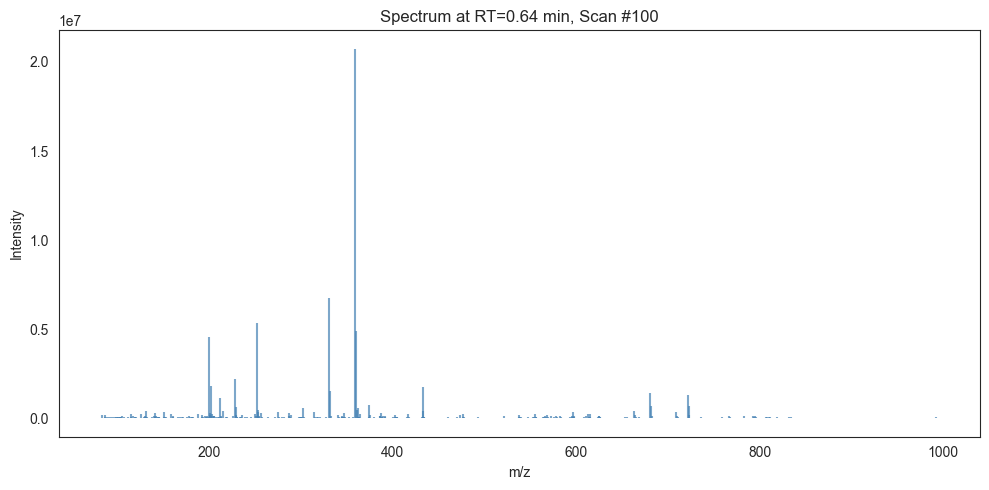

In [5]:
# 5 - visualizing a spectrum
# extract (m/z, intensity) pairs
mz, intensity = zip(*spectrum.peaks("centroided"))

# setup plot background and size
sns.set_style("white")
plt.figure(figsize=(10, 5))

# plot each peak as a vertical line
plt.vlines(mz, [0], intensity, color="steelblue", alpha=0.7)

# add labels and title
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Spectrum at RT={spectrum.scan_time[0]:.2f} min, Scan #{spectrum.ID}")

# adjust the layout so everything fits nicely in the plot
plt.tight_layout()
plt.show()

A scan is a snapshot of ion intensities across your mass spectrometer's m/z range at a specific point in time. In this mass spectrum (0.64 minutes), we see that the base peak (highest intensity peak) was observed at ~350 m/z. Let's zoom in here to get a closer look.

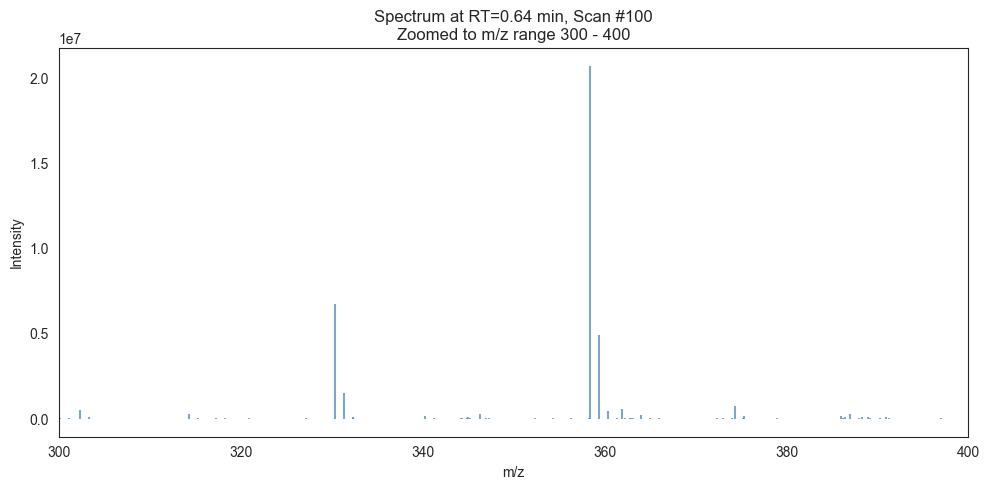

In [13]:
# 6 - Mass spec zoom in

mz_min, mz_max = 300, 400

# setup plot background and size
sns.set_style("white")
plt.figure(figsize=(10, 5))

# plot each peak as a vertical line
plt.vlines(mz, [0], intensity, color="steelblue", alpha=0.7)

# add labels and title
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(
    f"Spectrum at RT={spectrum.scan_time[0]:.2f} min, Scan #{spectrum.ID}\n"
    f"Zoomed to m/z range {mz_min} - {mz_max}"
)

# set x-axis limits
plt.xlim(mz_min, mz_max)

# adjust the layout so everything fits nicely in the plot
plt.tight_layout()
plt.show()

Zooming in with the above spectrum, we can clearly see the base peak at ~358 m/z, along with a lower intensity peak about 1 m/z higher. This pattern is consistent with an isotopic pattern and suggests that this is a genuine ion signal. 

Remember, LC-MS data is collected in three dimensions, retention time, intensity, and m/z. One scan represents just one retention time across the entire m/z range. Let's look at how this base peak changes across the entire retention time instead.

First, let's get the actual m/z of the base peak by filtering the m/z array to the highest intensity.

In [14]:
# 7 - first let's get the m/z of the base peak

# convert to numpy array
mz_arr = np.array(mz)
intensity_arr = np.array(intensity)

# subset to only peaks within the mz range of the plot above
# makes array of True/False values
mask = (mz_arr >= mz_min) & (mz_arr <= mz_max)

# apply the mask
filtered_mz = mz_arr[mask]
filtered_intensity = intensity_arr[mask]

# get index of max intensity
max_idx = np.argmax(filtered_intensity)

# get corresponding m/z and intensity
peak_mz = filtered_mz[max_idx]
peak_intensity = filtered_intensity[max_idx]

print(f"Peak m/z: {peak_mz:.4f}, intensity: {peak_intensity}")


Peak m/z: 358.3682, intensity: 20731922.0


With the base peak m/z, let's grab all the intensities for this m/z across the entire retention time range using the code blocks below.

In [36]:
# 8 - defining function to grab the retention times and intensities where we observe query peak


def find_mz(query_mz, ppm):
    rt = []
    intensity = []

    tolerance = query_mz * ppm / 1e6

    for spectrum in sample0:
        mz_array = spectrum.mz
        i_array = spectrum.i

        matched = [
            intensity
            for mz, intensity in zip(mz_array, i_array)
            if abs(mz - query_mz) <= tolerance
        ]

        if matched:
            try:
                scan_time = spectrum.scan_time_in_minutes()
            except AttributeError:
                scan_time = spectrum.scan_time

            rt.append(scan_time)
            intensity.append(sum(matched))

    if not rt:
        return pd.DataFrame(columns=["Sample", "RetentionTime", "Intensity"])

    rt, intensity = zip(*sorted(zip(rt, intensity)))

    return pd.DataFrame(
        {
            "Sample": os.path.basename(files[0]),
            "RetentionTime": rt,
            "Intensity": intensity,
        }
    )


In [37]:
# 9 - run find_mz

base_peak = 358.3682

data_df = find_mz(base_peak, ppm=5)
# look at the first 5 instances where we see this peak across retention time
data_df.head()

[Warning] Not index found and build_index_from_scratch is False


,Sample,RetentionTime,Intensity
0,batch14_MT_20210808_179.mzML,0.008583,38025148.0
1,batch14_MT_20210808_179.mzML,0.014984,50173500.0
2,batch14_MT_20210808_179.mzML,0.021160,52193492.0
3,batch14_MT_20210808_179.mzML,0.027340,53008712.0
4,batch14_MT_20210808_179.mzML,0.033714,52063292.0


### Plotting an Extracted Ion Chromatogram (EIC)

The data_df object contains all the retention times and corresponding intensity at that retention time of our highest peak 358.3682. Let's plot this (called an EIC).

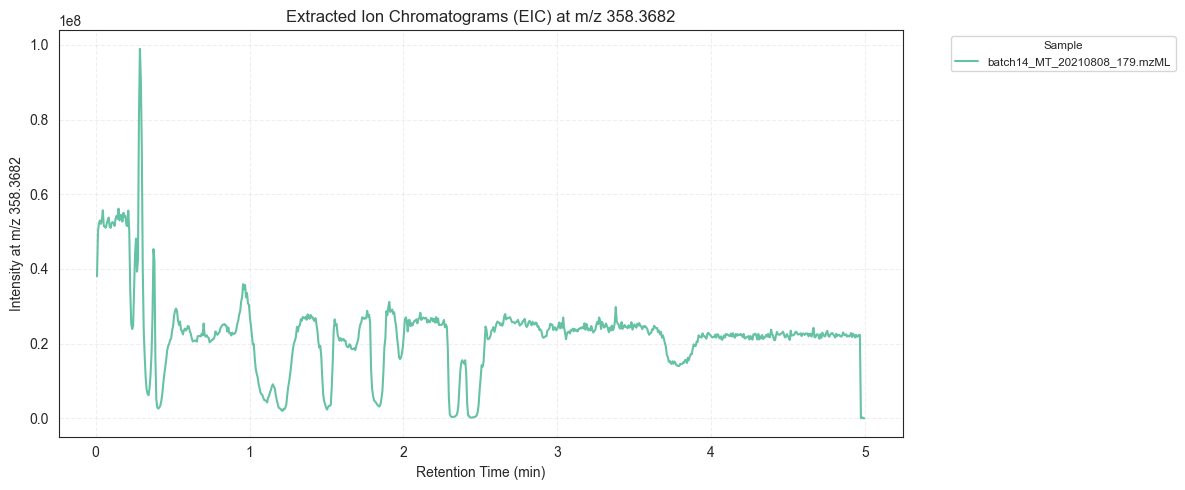

In [72]:
# 10 - define function for plotting eic
def plot_eic(query_peak, data_df):
    plt.figure(figsize=(12, 5))

    sns.lineplot(
        data=data_df,
        x="RetentionTime",
        y="Intensity",
        hue="Sample",
        palette="Set2",
    )

    plt.xlabel("Retention Time (min)")
    plt.ylabel(f"Intensity at m/z {query_peak:.4f}")
    plt.title(f"Extracted Ion Chromatograms (EIC) at m/z {query_peak:.4f}")

    plt.legend(
        title="Sample",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize="small",
        title_fontsize="small",
    )

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


# run plotting the eic of our base peak
plot_eic(base_peak, data_df)

In the EIC of the highest peak, we can see that it's highest intensity was actually seen around 0.25 minutes. Let's sort the data_df object to get the specifics.

In [ ]:
# 11 - getting the time of the base peak
max_row = data_df.sort_values("Intensity", ascending=False).iloc[0]
print(max_row)

Sample           /Users/chongj/Desktop/Li_Lab/Projects/Exposome...
RetentionTime                                             0.287417
Intensity                                            99228857.9375
Name: 44, dtype: object


### Exposome suspect screening

Now that we have a handle on scans, spectrums, and EICs, let's try to look for common exposome-related compounds in our data such as creatinine, which comes from dietary sources (animal protein), Gabapentin which is widely prescribed in the US. 

[Warning] Not index found and build_index_from_scratch is False


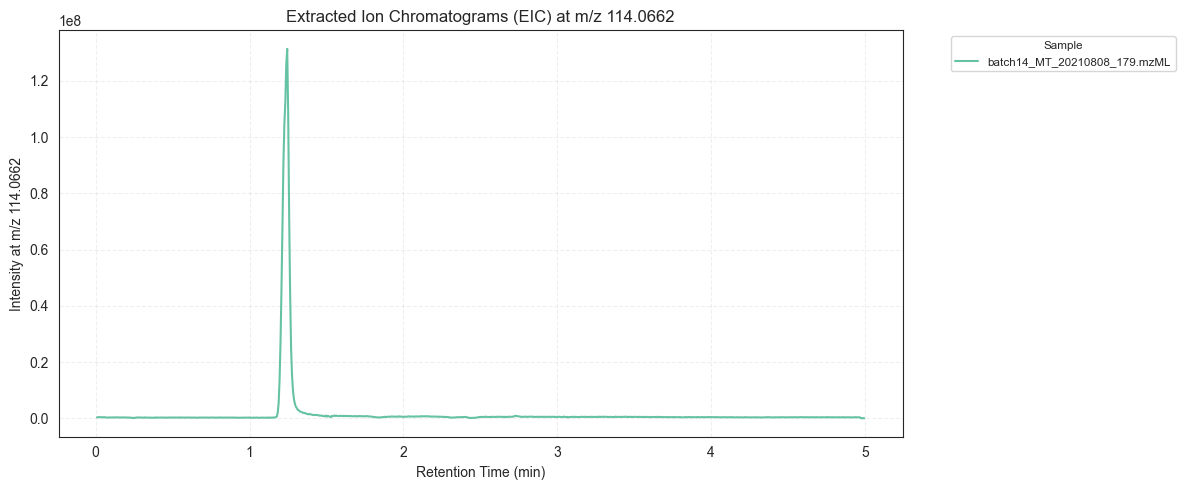

In [73]:
# 12 - Creatinine
# monoisotopic weight + proton mass (HILIC positive)
creatinine = 113.058911855 + 1.007276

creatinine_df = find_mz(creatinine, ppm=5)
creatinine_df.head()

plot_eic(creatinine, data_df=creatinine_df)

We see a strong peak at ~ 1.3 minutes for the m/z of creatinine!

Remember that an m/z match is only 1 piece of evidence for annotation, and we'd require another piece of orthogonal evidence such as matching retention time to an authentic standard or MS/MS fragmentation, isotope pattern information, to confidently annotate this compound.

[Warning] Not index found and build_index_from_scratch is False


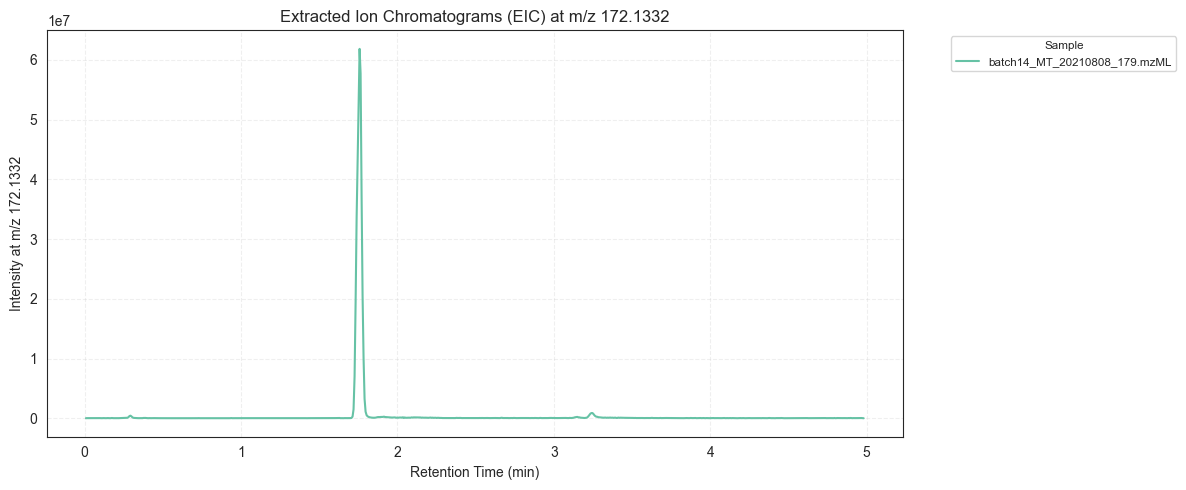

In [74]:
# 13 - Gabapentin
# monoisotopic weight + proton mass (HILIC positive)
gaba = 171.125928785 + 1.007276

gaba_df = find_mz(gaba, ppm=5)

plot_eic(gaba, data_df=gaba_df)

## Understanding the concept of mass tracks

*Mass tracks* are another fundamental unit for processing mass spectrometry data, first introduced by Li et al. with the Asari software. Its concept is similar to that of an EIC, where a mass track is an extracted ion chromatogram for a specific m/z value. It captures how that ion's intensity changes across the entire retention time in a single sample, with zeros filled in for scans where that m/z was not detected. As mass tracks are the fundamental building blocks of Asari's data model, they are built for all m/z values across the entire retention time in every single sample prior to peak picking.

In a traditional processing pipeline (XCMS, MZmine), aligning m/z across samples happens after peak detection. Whereas in Asari, per sample mass tracks are aligned across all samples into composite mass tracks, and peak detection happens using the composite structure.

Here, we will focus on exploring the structure of a mass track and visualizing it.

In **extract_massTracks_**, all parameters are default values. The mz_tolerance_ppm is used to merge m/z values into a single mass track. Minimum intensity, timepoints, and peak heights are quality thresholds to determine if mass tracks should be retained for further processing.

You can ignore all warnings in the block below.

In [75]:
# 14 - extract mass tracks
# note: you can ignore any user warnings
from asari import chromatograms as ch

# get mass tracks from the first sample
mass_tracks = ch.extract_massTracks_(
    infile,
    mz_tolerance_ppm=5,
    min_intensity=100,
    min_timepoints=5,
    min_peak_height=1000,
)

# list all the keys in mass_tracks (dictionary)
print(f"Mass track keys: {mass_tracks.keys()}")

[Warning] Not index found and build_index_from_scratch is False
[Warning] Not index found and build_index_from_scratch is False
Mass track keys: dict_keys(['rt_numbers', 'rt_times', 'tracks', 'ms2_spectra', 'acquisition_time'])


The mass track object contains five keys:

* rt_numbers = scan number
* rt_times = retention times for each scan number
* tracks = the tracks; list of EICs for all detected m/z values
* ms2_spectra = if this was DDA data, ms2 spectra would be stored here, but it's not used to build mass tracks
* acquistion_time = the timestamp of when the experiment was run (only 1)

rt_number, rt_times, and tracks are co-indexed.

Now let's check what a track actually looks like.

In [76]:
# 15 - get number of mass tracks
print(f"N Mass tracks: {len(mass_tracks['tracks'])}")

N Mass tracks: 7385


From above we know there are 785 scans, which are 785 snapshots over acquisition time (ie 785 timepoints). Here we can see there are 7385 mass tracks, meaning 7385 unique m/z values (within a 5 ppm tolerance) captured in our file.

In [77]:
# 16 - mass track 115
# let's look what a track is made of
# note it is made of two elements
# 1 - a float (np.float64) - m/z value for this track
# 2 - an array - intensity values across retention time
print("Components of a track: [( mz, np.array(intensities at full rt range) ), ...]")
mass_tracks["tracks"][115]  # selecting track 115

Components of a track: [( mz, np.array(intensities at full rt range) ), ...]


(98.97530746459961,
 array([      0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,    9798,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,    8189,
              0,       0,       0,    9128,       0,     

In the output above, we can see that mass track 115 is for an ion at 97.0396 m/z, and the array contains that ion's intensity across retention time. Let's confirm that there are 785 intensity values, which correspond to each timepoint.

In [78]:
# 17 - mass track 115 - number of intensity values
len(mass_tracks["tracks"][115][1])

785

Now that we have a handle on what's a mass track, let's plot it!

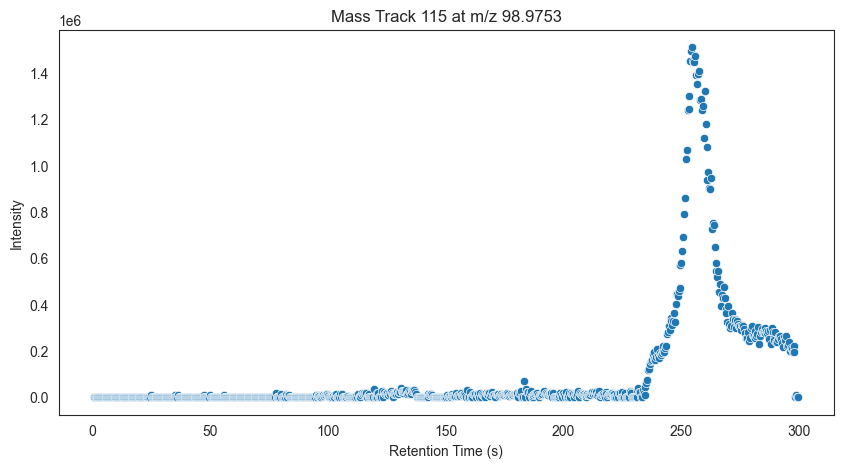

In [79]:
# 18 - visualize track 115
track_number = 115

this_mz = mass_tracks["tracks"][track_number][0]
intensity = mass_tracks["tracks"][track_number][1]
rt_times = mass_tracks["rt_times"]

# setup DataFrame
df = pd.DataFrame({"Retention Time": rt_times, "Intensity": intensity})

# set figure size
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="Retention Time", y="Intensity")

plt.title(f"Mass Track {track_number} at m/z {this_mz:.4f}")
plt.xlabel("Retention Time (s)")
plt.ylabel("Intensity")
plt.show()

The above plot shows the intensity of mass track 115 as a function of retention time, visualized as a scatterplot. Each point represents an individual MS scan across the chromatographic run. A single peak with a good Gaussian shape , indicating a well-defined elution profile with high signal-to-noise ratio for this m/z value.

# Summary

Code here is meant for illustrations. Some of the above functions are already covered in the Asari package. 

There are endless possibilities after you master the fundamentals. You can explore data, write your own tools, and contribute to the Asari suite!